 # 4D-OBC Seed extraction
 
This notebook explains how to use the extraction-function of the py4dgeo-packag which extracts 4D-objects-by-change automatically from a point-cloud, by using either the Ramer-Douglas-Peucker-algorithm (RDP) or a Decision-Tree-Regressor (DTR).

Implemented in: `py4dgeo.extract`

**Author(s)** 

Scharnagl, Robin (Technische Universität München)

**Related publication**

 Ulm M, Elias M,  Eltner A, Lotsari E & Anders K. (2025). Automated change detection in photogrammetric 4D point clouds – transferability and extension of 4D objects‑by‑change 
for monitoring riverbank dynamics using low‑cost cameras. *Applied Geomatics*, https://doi.org/10.1007/s12518-025-00623-9   


## **Method description**
This section should provide a detailed technical explanation of the method:

- **Theoretical foundation**: To detect changes in a surface, this algorithm uses distances from a M3C2 point-cloud comparison to detect linear changes of the surface. 
Two different methods are available:

    - The Ramer–Douglas–Peucker (RDP) algorithm simplifies the time-series curve of each core point, dividing it into polygons (segments) that represent approximately linear trends.

    - The Decision Tree Regressor (DTR) estimates the local gradient (rate of change) of each time series and groups similar gradients together to form regions with nearly constant slope.

    Both approaches aim to find and quantify sections of linear change in the point cloud distance data.
- **Algorithm**: The alorithm detects linear temporal changes at each core-point in a  point cloud. If a linear change exceeds a user-defined threshold, it gets added to a list of seed candidates. 
    - **Ramer-Douglas-Peucker:** By using the RDP-method, the time-series of a corepoint gets divided into segments of (approximately) linear change. These segments are then expanded, as long as the amplitude exceeds the user-definded height-threshold, and the temporal length is shorter tahn the user-defined max_change_period. The valid segments are then stored as seeds with their intervals, which are then sorted according to their change magnitude.
    - **Decision Tree Regressor:** With the Decision-Tree-Regressor approach, the regressor splits the data into regions with similar values, which is the rate-of-change in this case. If the slope is roughly constant, the data behaves lineraly. Therefore, for each core point, teh gradient is calculated, which is then used by the Decision Tree Regressor, to create regions of constant slope. For each of these regions, a linear regression is fit, expanded, and filtered based on the amplitude threshold and the maximum duration. These are then sorted based on change magnitude.

- **Key parameters**: Optional parameters, that can be given to the alogrithm:
    - `seed_subsampling` (int): reduces the number of seedpoints, that are taken into account
    - `max_change_period` (int): the maximum number of epochs for a segment-length
    - `neighborhood_radius` (float): defines the spatial neighbourhood used during region growing
    - `minperiod` (int): minimum number of epochs of each segment 
    - `max_change_period` (int): maximum number of epoch of each segment 
    - `height_threshold` (float): minimum change required to be accepted as a seed
    - `data_gap` (int or None): forbids seeds crossing a known missing-data epoch


First, we download the dataset, and sort the files according to their dates:

In [1]:
# Load Required Package
import pooch
import os
from datetime import datetime
import py4dgeo


# Load Dataset
# Download data from zenodo and set path to point cloud folder
p = pooch.Pooch(base_url="doi:10.5281/zenodo.10003574/", path=pooch.os_cache("py4dgeo"))
p.load_registry_from_doi()
p.fetch("module3.zip", processor=pooch.Unzip(), progressbar=True)
pc_dir = p.path / "module3.zip.unzip" / "module3" / "schneeferner" / "pointclouds"

def parse_timestamp(fname):
    ts_str = "_".join(fname.split(".")[0].split("_")[1:])  # YYMMDD_hhmmss
    return datetime.strptime(ts_str, "%y%m%d_%H%M%S")

pc_files = sorted(
    (f for f in os.listdir(pc_dir) if f.endswith(".laz")),
    key=parse_timestamp,
)
timestamps = [parse_timestamp(f) for f in pc_files]

We then set up the SpatiotemporalAnalyssis-object. We set the reference_epoch as the first file, and the point cloud of that epoch as the corepoints. We then calculate the M3C2 distances over the whole ime series. 

In [3]:
analysis = py4dgeo.SpatiotemporalAnalysis(str(pc_dir / "schneeferner.zip"), force=True)
# read the reference epoch and set the timestamp
reference_epoch = py4dgeo.read_from_las(str(pc_dir /pc_files[0]))
reference_epoch.timestamp = timestamps[0]

# set the reference epoch in the spatiotemporal analysis object and use the points as the corepoints
analysis.reference_epoch = reference_epoch
analysis.corepoints = reference_epoch.cloud

# distance calculation
analysis.m3c2 = py4dgeo.M3C2(cyl_radius=2.0, normal_radii=[2.0])
epochs_to_add = []
for fname, ts in zip(pc_files[1:], timestamps[1:]):
    epoch = py4dgeo.read_from_las(str(pc_dir / fname))
    epoch.timestamp = ts
    epochs_to_add.append(epoch)
    
analysis.add_epochs(*epochs_to_add)

[2026-08-25 13:05:13][INFO] Creating analysis file C:\Users\schar\AppData\Local\py4dgeo\py4dgeo\Cache\module3.zip.unzip\module3\schneeferner\pointclouds\schneeferner.zip
[2026-08-25 13:05:13][INFO] Reading point cloud from file 'C:\Users\schar\AppData\Local\py4dgeo\py4dgeo\Cache\module3.zip.unzip\module3\schneeferner\pointclouds\schneeferner_180418_120027.laz'
[2026-08-25 13:05:13][INFO] Building KDTree structure with leaf parameter 10
[2026-08-25 13:05:13][INFO] Saving epoch to file 'C:\Users\schar\AppData\Local\Temp\tmpvi8rqfdc\reference_epoch.zip'
[2026-08-25 13:05:13][INFO] Saving a file without normals.
[2026-08-25 13:05:14][INFO] Initializing Epoch object from given point cloud
[2026-08-25 13:05:14][INFO] Building KDTree structure with leaf parameter 10
[2026-08-25 13:05:14][INFO] Saving epoch to file 'C:\Users\schar\AppData\Local\Temp\tmp_q6murqt\corepoints.zip'
[2026-08-25 13:05:14][INFO] Saving a file without normals.
[2026-08-25 13:05:14][INFO] Reading point cloud from file '

The next step is setting up the RegionGrowingAlgorithm. We can speecify which method we want to use. There are three methods available:'linear_rdp' (Ramer Douglas Peucker), 'linear_dtr' (Decision Tree Regression) and 'volume_cpd' (to assure backward compatibility, this mehtod is the default, when no method is given)

In [41]:
algo = py4dgeo.RegionGrowingAlgorithm(
        neighborhood_radius = 2.0,
        seed_subsampling= 50,
        height_threshold= 0.5, 
        minperiod = 48, 
        method= 'linear_rdp' # 'linear_rdp', 'linear_dtr' or 'volume_cpd'
)

objects = algo.run(analysis)

[2026-08-25 13:32:41][INFO] Starting: Find seed candidates in time series


[2026-08-25 13:32:42][INFO] Iterating over seedpoints (RDP)
[2026-08-25 13:34:36][INFO] Finished in 114.5455s: Find seed candidates in time series
[2026-08-25 13:34:36][INFO] Starting: Sort seed candidates by priority
[2026-08-25 13:34:37][INFO] Finished in 0.8477s: Sort seed candidates by priority
[2026-08-25 13:34:37][INFO] Starting: Performing region growing on seed candidate 1/3716
[2026-08-25 13:34:37][INFO] Finished in 0.0021s: Performing region growing on seed candidate 1/3716
[2026-08-25 13:34:37][INFO] Starting: Performing region growing on seed candidate 2/3716
[2026-08-25 13:34:37][INFO] Finished in 0.0013s: Performing region growing on seed candidate 2/3716
[2026-08-25 13:34:37][INFO] Starting: Performing region growing on seed candidate 3/3716
[2026-08-25 13:34:37][INFO] Finished in 0.0015s: Performing region growing on seed candidate 3/3716
[2026-08-25 13:34:37][INFO] Starting: Performing region growing on seed candidate 4/3716
[2026-08-25 13:34:40][INFO] Finished in 2.87

We can then visually inspect objects like this: 

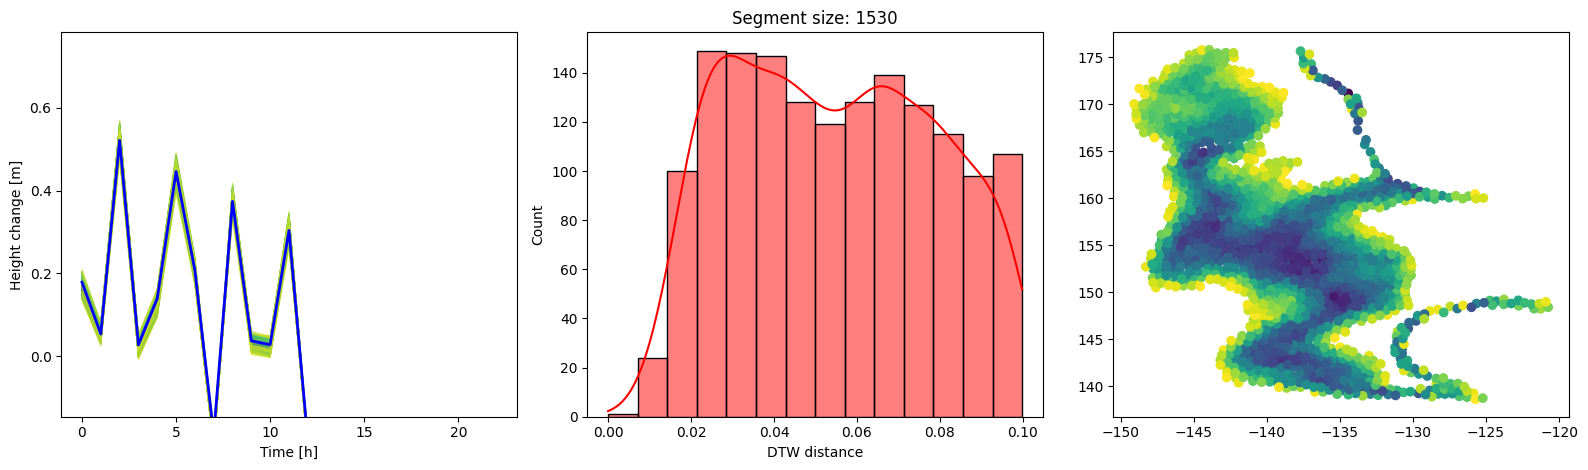

In [36]:
obj = objects[25]
obj.plot()

In [40]:
# to change parameters in the algorithm, the results need to be invalidted first. Otherwise, the previously computed seeds and objects will be used
analysis.invalidate_results(seeds=True, objects=True)

[2026-08-25 13:32:33][INFO] Removing intermediate results from the analysis file C:\Users\schar\AppData\Local\py4dgeo\py4dgeo\Cache\module3.zip.unzip\module3\schneeferner\pointclouds\schneeferner.zip


## References
-  Ulm M, Elias M,  Eltner A, Lotsari E & Anders K. (2025). Automated change detection in photogrammetric 4D point clouds – transferability and extension of 4D objects‑by‑change 
for monitoring riverbank dynamics using low‑cost cameras. *Applied Geomatics*, pages. https://doi.org/10.1007/s12518-025-00623-9   